# This notebook includes a Deceptive Max Ones implementation

This example shows how we add a loop for running the evolutionary algorithm multiple times, and collecting and presenting the results.

In [ ]:
import random
import numpy
import matplotlib.pyplot as plt
%matplotlib inline
from deap import algorithms, base, creator, tools

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=18)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

The only thing we need to do is change the evaluation function so that it works in blocks of three, like this.

In [ ]:
def evalOneMaxDeceptive(individual):
    fitness = 0

    for i in range(0, len(individual), 3):
        indlen = sum(individual[i:i + 3])
        if indlen == 0:
            fitness += 0.9
        elif indlen == 1:
            fitness += 0.8
        elif indlen == 2:
            fitness += 0.0
        else:
            fitness += 1.0

    return (fitness,)

In [ ]:
toolbox.register("evaluate", evalOneMaxDeceptive)
toolbox.register("select", tools.selTournament, tournsize=3)

toolbox.register("mate", tools.cxUniform, indpb=0.1)
#toolbox.register("mate", tools.cxTwoPoint)

toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)

In [ ]:
logbook = tools.Logbook()
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean)
stats.register("std", numpy.std)
stats.register("min", numpy.min)
stats.register("max", numpy.max)

In [ ]:
def resetPopulation(popSize):
    pop = toolbox.population(n=popSize)
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit
    return pop

In [ ]:
NGEN = 100
NRUNS = 50

avgRuns = [None] * NRUNS #

for run in range(NRUNS):#
    print("-- RUN %i --" % run)
    pop = resetPopulation(popSize=100) #

    for g in range(NGEN):

        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

        for mutant in offspring:
            toolbox.mutate(mutant)
            del mutant.fitness.values

        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
             ind.fitness.values = fit

        pop[:] = offspring

        record = stats.compile(pop)
        logbook.record(gen=g, **record)

    avgs = logbook.select("avg") #
    avgRuns[run] = avgs[-1]      #

In [ ]:
print(avgRuns)

[5.5280000000000005, 5.5820000000000025, 5.735999999999999, 5.543000000000003, 5.735999999999999, 5.620000000000002, 5.537000000000001, 5.806999999999999, 5.602000000000001, 5.758999999999998, 5.610000000000003, 5.645000000000003, 5.705999999999997, 5.674999999999998, 5.654999999999998, 5.617000000000003, 5.684999999999997, 5.653999999999999, 5.492000000000001, 5.672999999999997, 5.600000000000003, 5.5500000000000025, 5.600000000000002, 5.490000000000001, 5.625000000000003, 5.531000000000001, 5.611000000000003, 5.584000000000002, 5.563000000000004, 5.5870000000000015, 5.505000000000001, 5.641999999999997, 5.621000000000001, 5.603999999999997, 5.680999999999998, 5.638000000000003, 5.624999999999997, 5.604000000000003, 5.529000000000002, 5.613000000000003, 5.674000000000002, 5.697999999999997, 5.6789999999999985, 5.591000000000004, 5.505000000000003, 5.691999999999997, 5.7019999999999955, 5.673999999999996, 5.605999999999998, 5.625999999999998]


(array([2.52365931, 3.78548896, 1.89274448, 6.94006309, 5.67823344,
        4.41640379, 3.78548896, 1.26182965, 0.63091483, 0.63091483]),
 array([5.49  , 5.5217, 5.5534, 5.5851, 5.6168, 5.6485, 5.6802, 5.7119,
        5.7436, 5.7753, 5.807 ]),
 <a list of 10 Patch objects>)

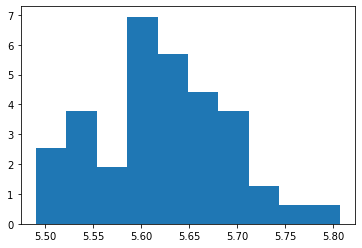

In [ ]:
plt.hist(avgRuns, density=True, bins=10)